# Stock Price Forecasting - Exploratory Data Analysis

This notebook performs comprehensive exploratory data analysis on stock price data for forecasting with ARIMA and XGBoost models.

**Dataset**: Yahoo Finance via yfinance  
**Tickers**: AAPL, MSFT, GOOGL, AMZN, TSLA  
**Period**: 2015-01-01 to 2025-11-23

## Sections
1. Install and Import Libraries
2. Download Data with yfinance
3. Verify Downloaded Data
4. Price and Volume Visualization
5. Moving Averages Analysis
6. Volatility Analysis
7. Returns Distribution
8. ACF/PACF for ARIMA
9. Correlation Analysis
10. Alternative Data Sources

## 1. Install and Import Required Libraries

In [1]:
# Install required packages (uncomment if needed)
# !pip install yfinance pandas numpy matplotlib seaborn mplfinance scipy statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Download Data with yfinance

Using Yahoo Finance API to download OHLCV data for multiple tickers with multi-threading for efficiency.

In [2]:
# Define tickers and date range
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
start_date = "2015-01-01"
end_date = "2025-11-23"

print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")
print(f"Tickers: {', '.join(tickers)}\n")

# Download data with multi-threading
df = yf.download(
    tickers, 
    start=start_date, 
    end=end_date, 
    group_by='ticker', 
    threads=True,
    progress=True
)

print(f"\n✓ Download complete!")
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Tickers: AAPL, MSFT, GOOGL, AMZN, TSLA



[*********************100%***********************]  5 of 5 completed


✓ Download complete!
Data shape: (2740, 25)
Date range: 2015-01-02 00:00:00 to 2025-11-21 00:00:00


## 3. Verify Downloaded Data

Check structure, display sample rows, and verify data quality.

In [3]:
# Display first few rows
print("First 5 rows of data:")
print(df.head())

# Display summary info for each ticker
for ticker in tickers:
    ticker_df = df[ticker]
    print(f"\n{ticker} Summary:")
    print(f"  Rows: {len(ticker_df)}")
    print(f"  Missing values: {ticker_df.isnull().sum().sum()}")
    print(f"  Columns: {list(ticker_df.columns)}")
    print(f"  Price range: ${ticker_df['Close'].min():.2f} - ${ticker_df['Close'].max():.2f}")


First 5 rows of data:
Ticker         AMZN                                            TSLA  \
Price          Open     High      Low    Close    Volume       Open   
Date                                                                  
2015-01-02  15.6290  15.7375  15.3480  15.4260  55664000  14.858000   
2015-01-05  15.3505  15.4190  15.0425  15.1095  55484000  14.303333   
2015-01-06  15.1120  15.1500  14.6190  14.7645  70380000  14.004000   
2015-01-07  14.8750  15.0640  14.7665  14.9210  52806000  14.223333   
2015-01-08  15.0160  15.1570  14.8055  15.0230  61768000  14.187333   

Ticker                                                 ...       MSFT  \
Price            High        Low      Close    Volume  ...       Open   
Date                                                   ...              
2015-01-02  14.883333  14.217333  14.620667  71466000  ...  39.773213   
2015-01-05  14.433333  13.810667  14.006000  80527500  ...  39.526014   
2015-01-06  14.280000  13.614000  14.085333 

## 4. Price and Volume Visualization

### 4.1 Adjusted Close Price Time Series

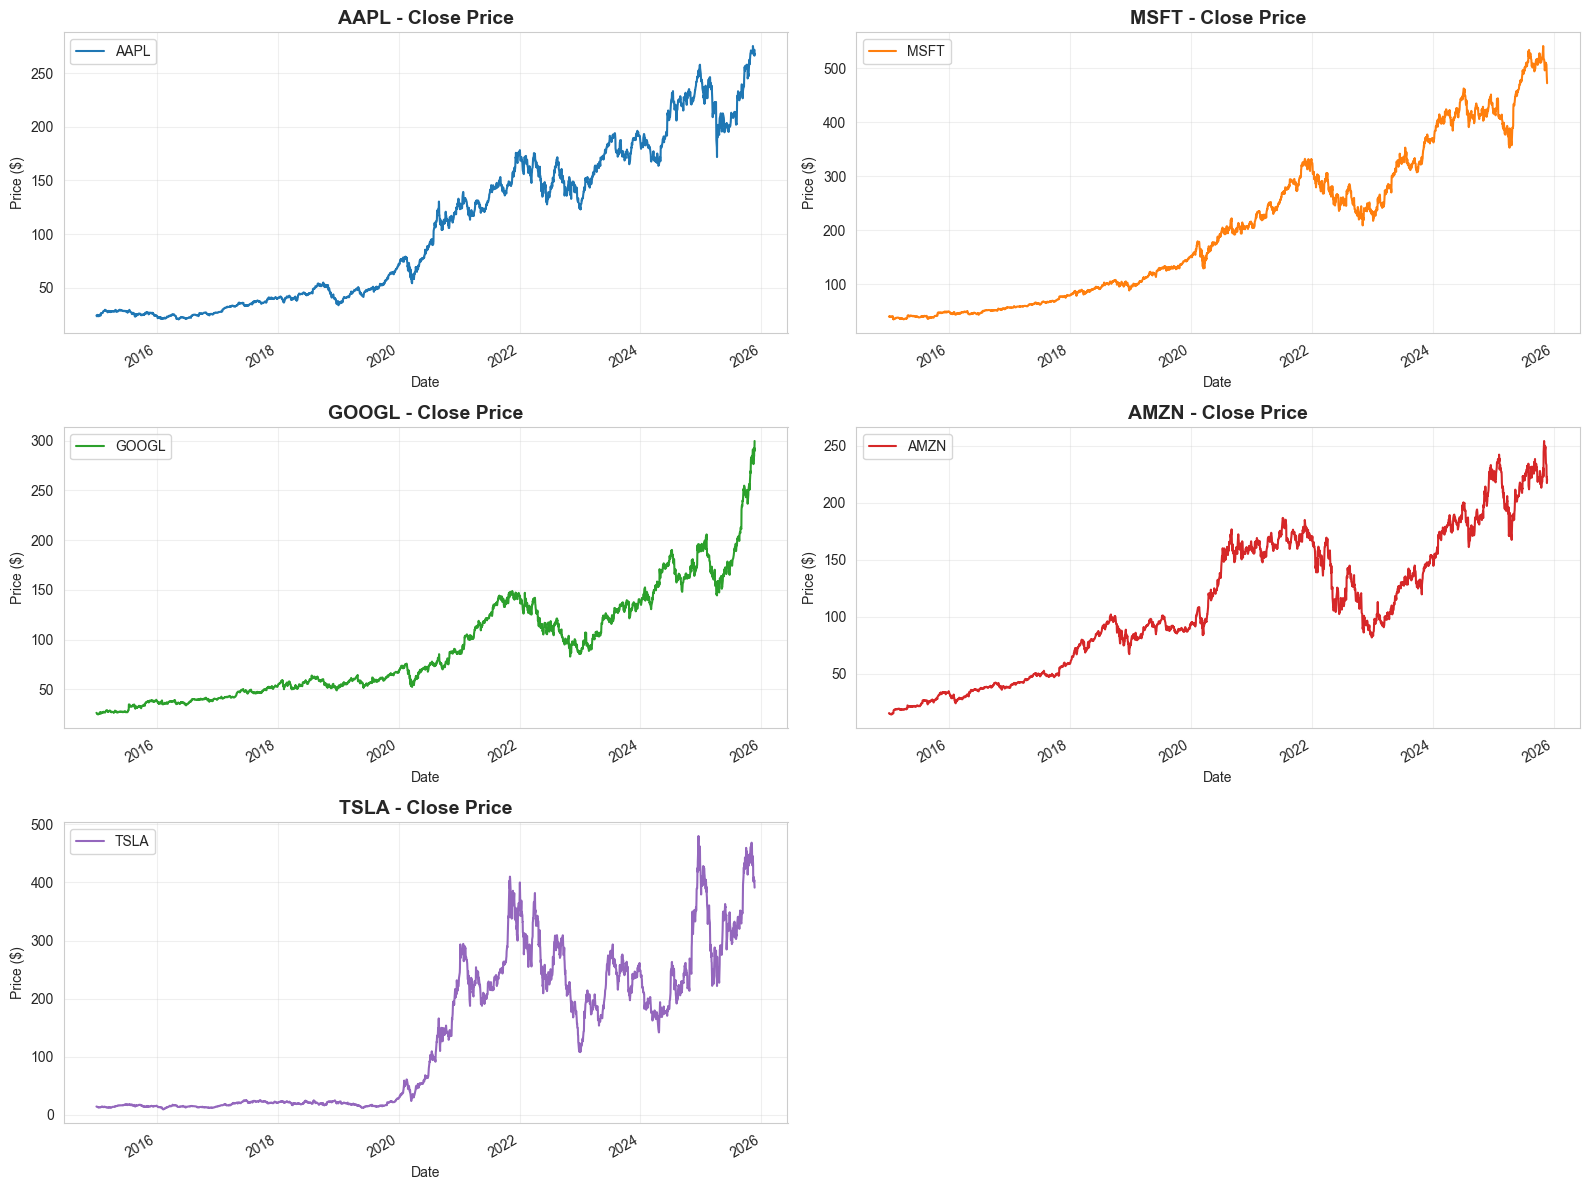

In [4]:
# Plot close prices for all tickers
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    df[ticker]['Close'].plot(ax=ax, linewidth=1.5, color=sns.color_palette()[i])
    ax.set_title(f'{ticker} - Close Price', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
    ax.legend([ticker])

# Remove extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


### 4.2 Candlestick Chart (Recent 6 months for AAPL)

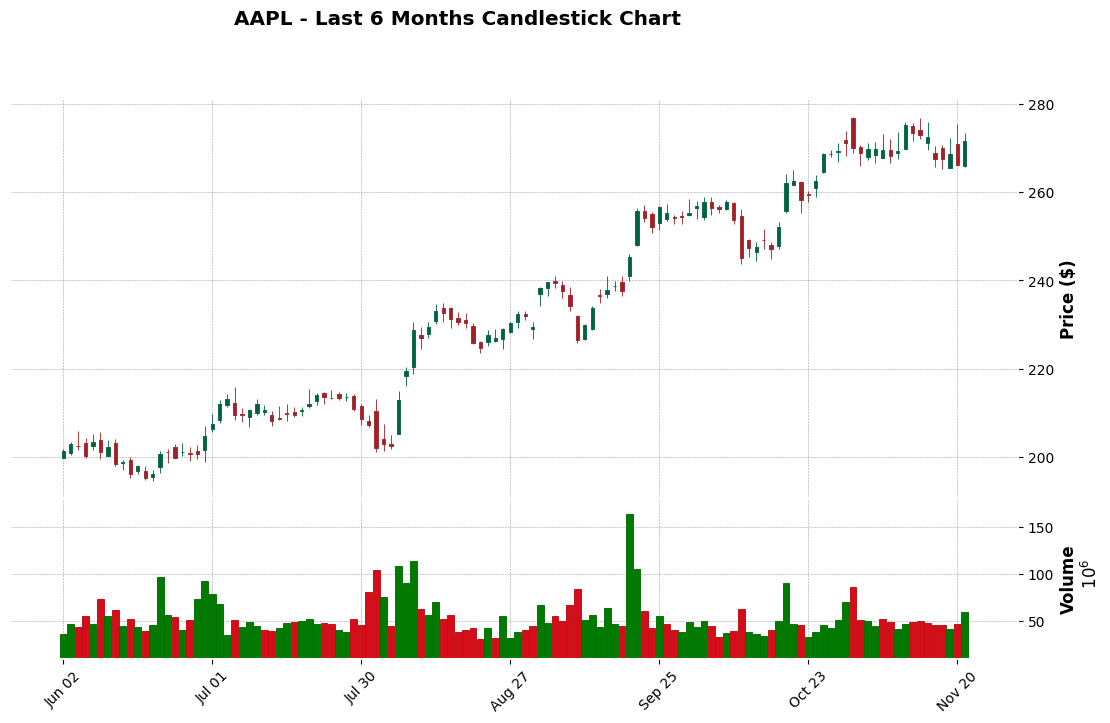

In [5]:
# Candlestick chart for AAPL (last 6 months)
aapl_recent = df['AAPL'].last('6M')

mpf.plot(
    aapl_recent,
    type='candle',
    volume=True,
    style='charles',
    title='AAPL - Last 6 Months Candlestick Chart',
    ylabel='Price ($)',
    ylabel_lower='Volume',
    figsize=(14, 8)
)

### 4.3 Volume Analysis

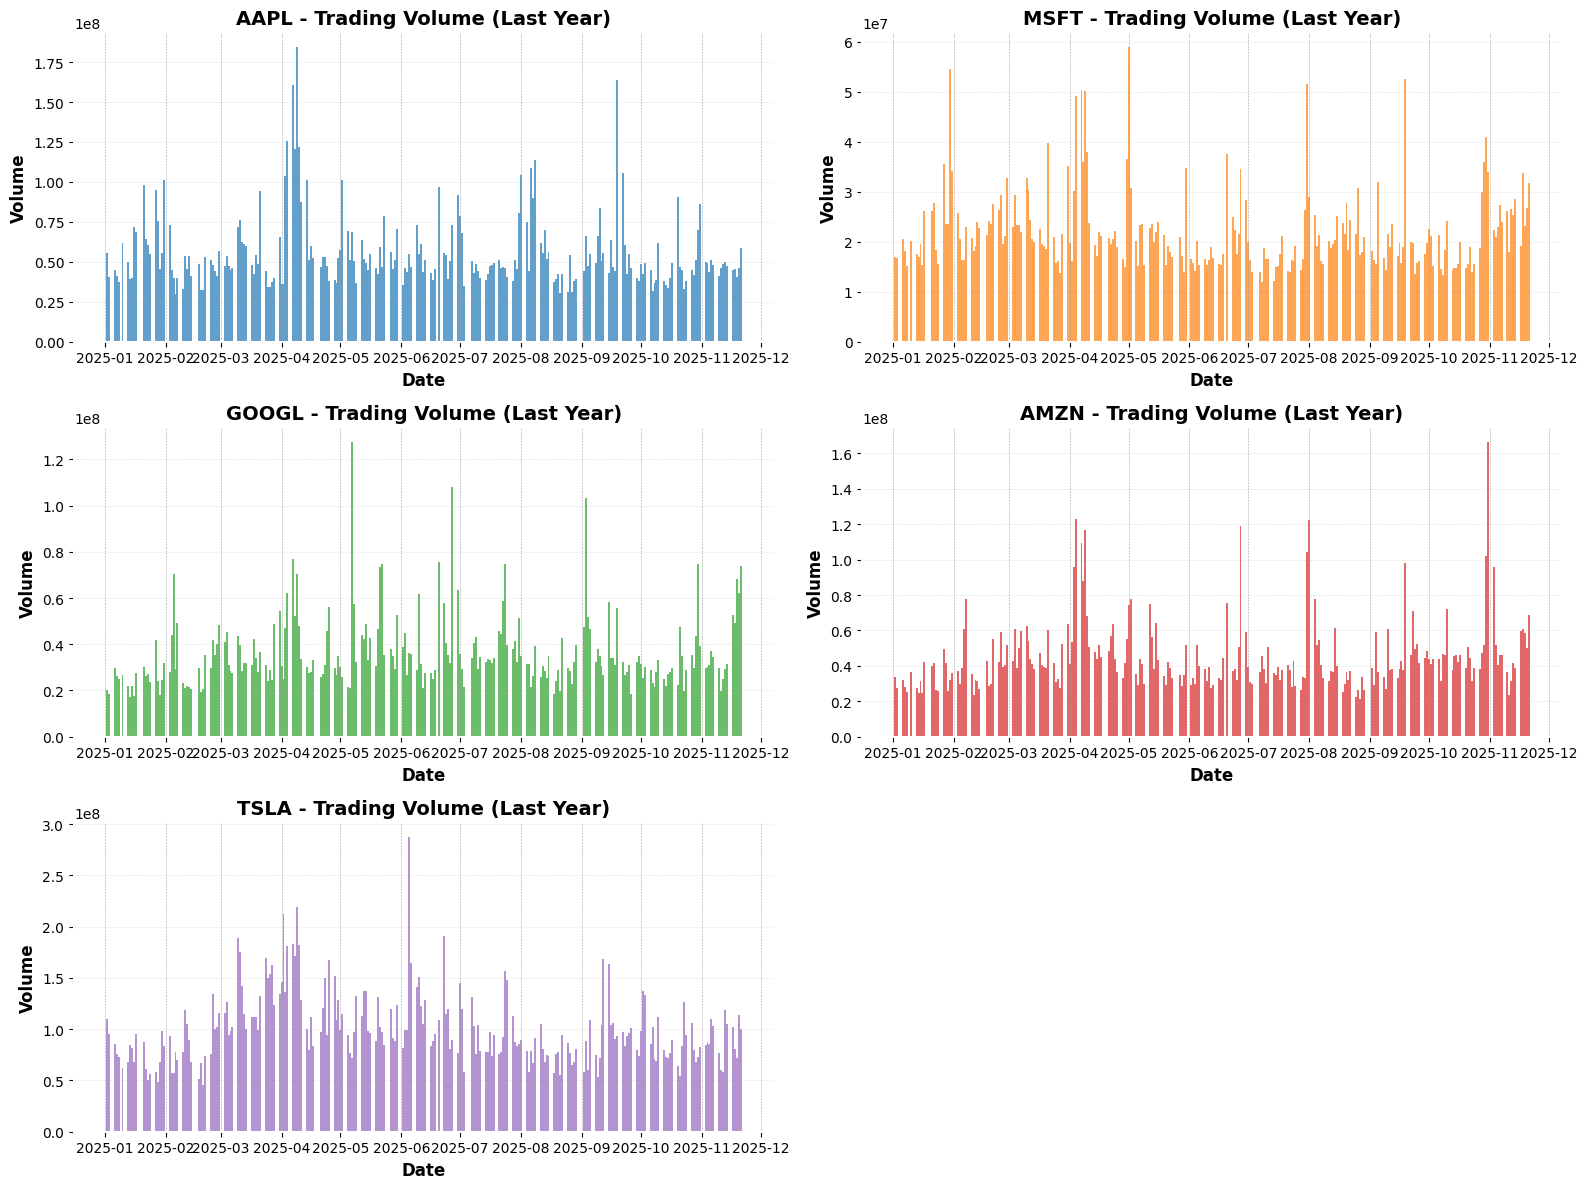

In [6]:
# Volume bar charts
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    # Plot volume (recent 1 year for clarity)
    volume_data = df[ticker]['Volume'].last('1Y')
    ax.bar(volume_data.index, volume_data.values, width=1, alpha=0.7, 
           color=sns.color_palette()[i])
    ax.set_title(f'{ticker} - Trading Volume (Last Year)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Volume')
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 5. Moving Averages Analysis

Overlay 20-day, 50-day, and 200-day moving averages on price charts.

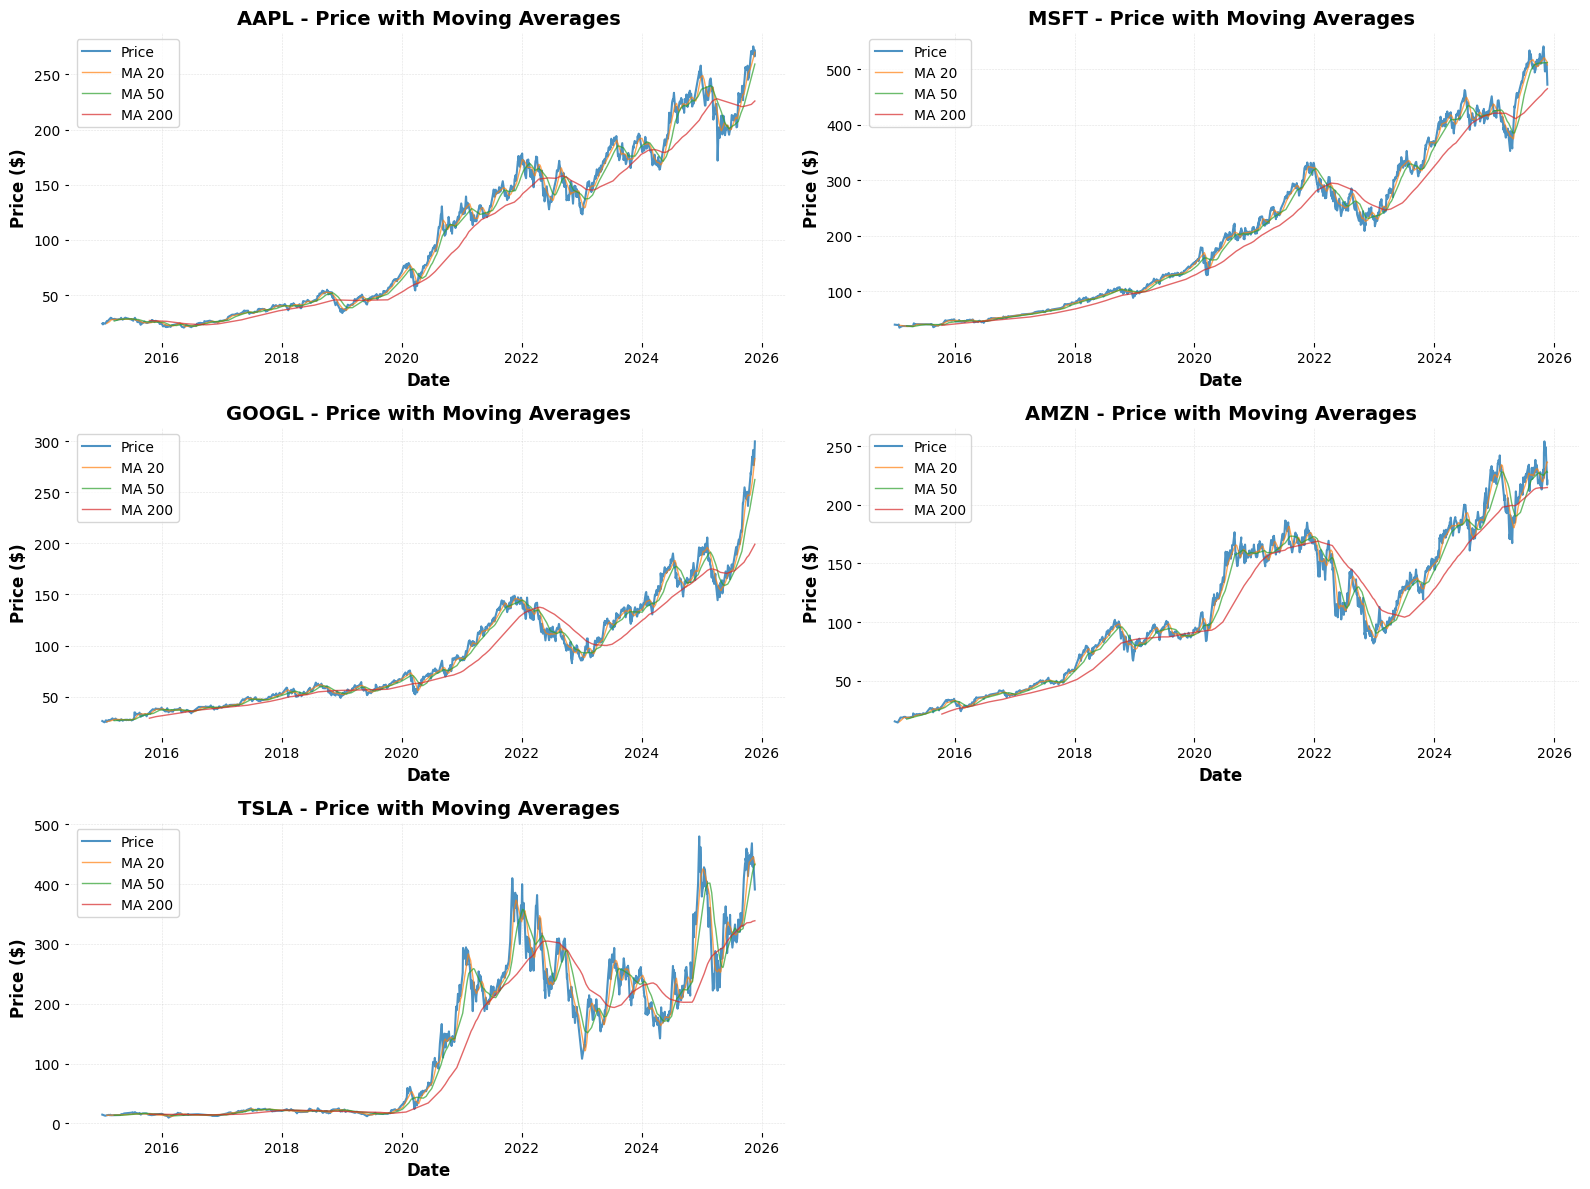

In [7]:
# Calculate moving averages for each ticker
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    
    ticker_df = df[ticker].copy()
    
    # Calculate MAs
    ticker_df['MA_20'] = ticker_df['Close'].rolling(window=20).mean()
    ticker_df['MA_50'] = ticker_df['Close'].rolling(window=50).mean()
    ticker_df['MA_200'] = ticker_df['Close'].rolling(window=200).mean()
    
    # Plot
    ax.plot(ticker_df.index, ticker_df['Close'], label='Price', linewidth=1.5, alpha=0.8)
    ax.plot(ticker_df.index, ticker_df['MA_20'], label='MA 20', linewidth=1, alpha=0.7)
    ax.plot(ticker_df.index, ticker_df['MA_50'], label='MA 50', linewidth=1, alpha=0.7)
    ax.plot(ticker_df.index, ticker_df['MA_200'], label='MA 200', linewidth=1, alpha=0.7)
    
    ax.set_title(f'{ticker} - Price with Moving Averages', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 6. Volatility Analysis

Calculate and visualize rolling volatility (20-day standard deviation of log returns).

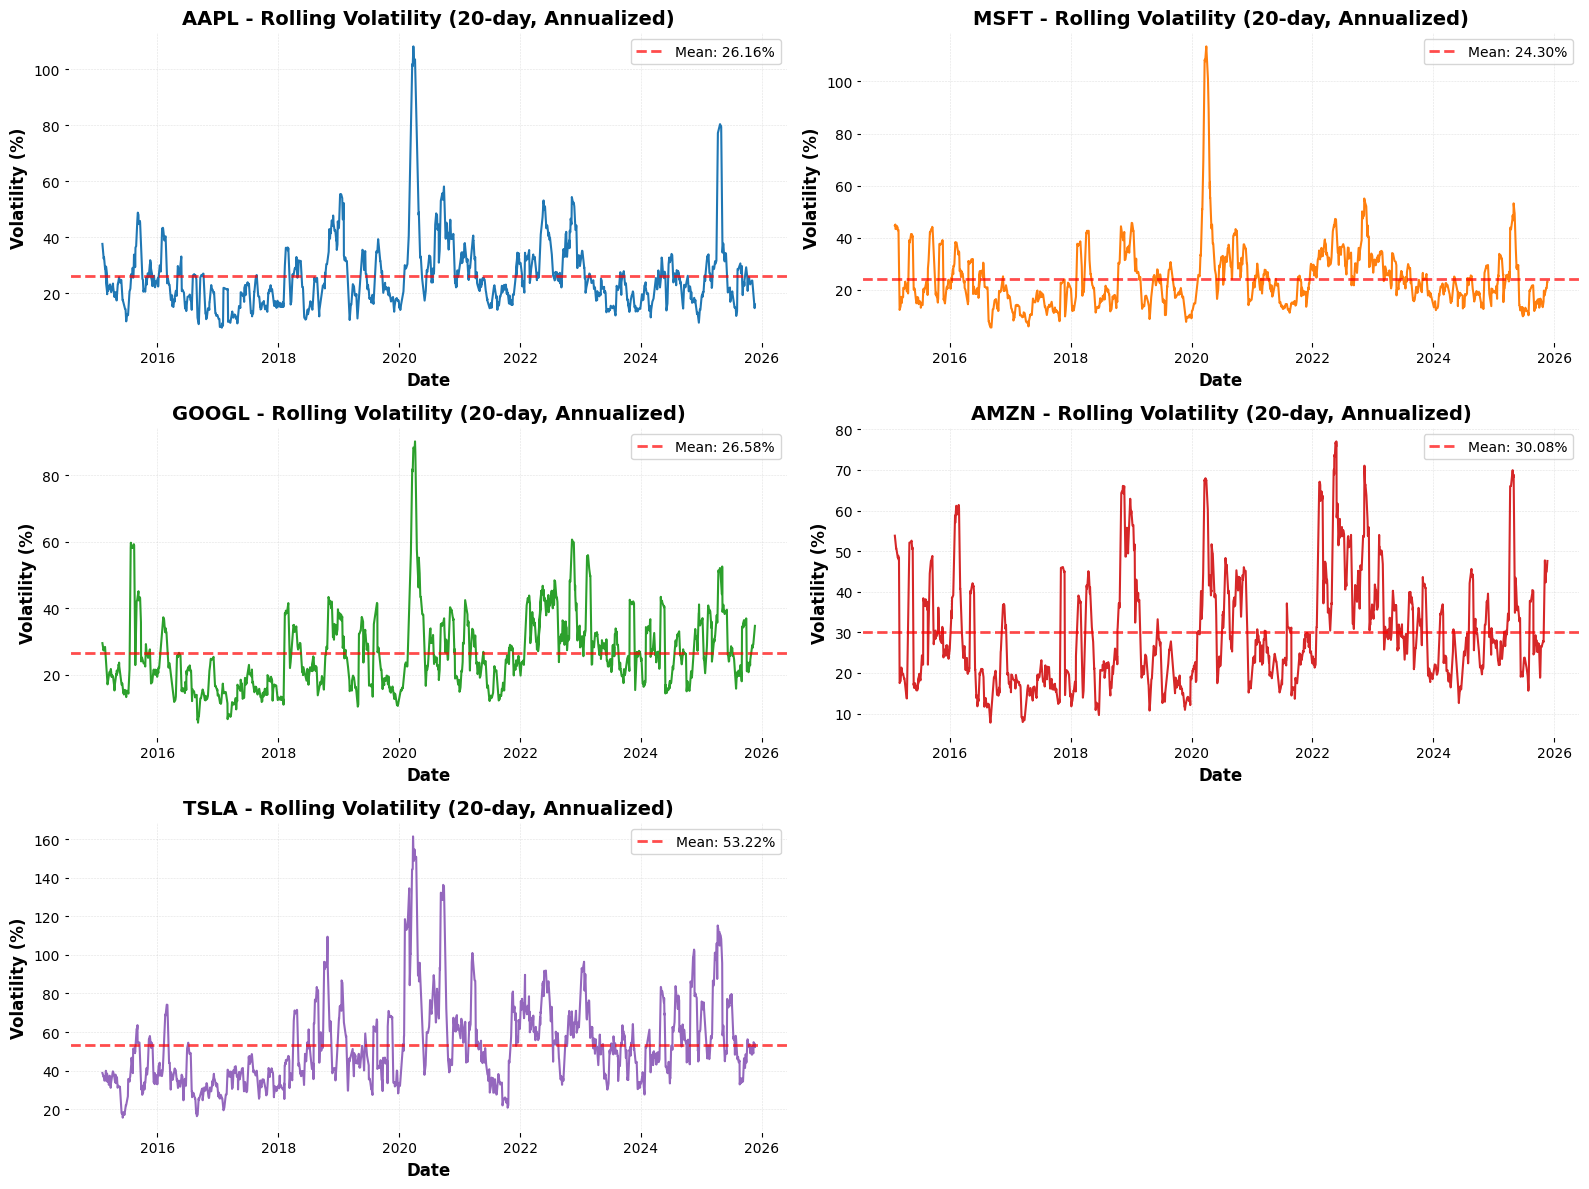

In [8]:
# Calculate and plot rolling volatility
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    
    # Calculate log returns
    ticker_df = df[ticker].copy()
    ticker_df['LogReturn'] = np.log(ticker_df['Close']).diff()
    
    # Calculate 20-day rolling volatility
    ticker_df['Volatility'] = ticker_df['LogReturn'].rolling(window=20).std() * np.sqrt(252) * 100
    
    ax.plot(ticker_df.index, ticker_df['Volatility'], linewidth=1.5, 
            color=sns.color_palette()[i])
    ax.axhline(y=ticker_df['Volatility'].mean(), color='red', linestyle='--', 
               alpha=0.7, label=f'Mean: {ticker_df["Volatility"].mean():.2f}%')
    
    ax.set_title(f'{ticker} - Rolling Volatility (20-day, Annualized)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Volatility (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 7. Returns Distribution Analysis

Analyze distribution of daily returns including histogram, Q-Q plot, and kurtosis.

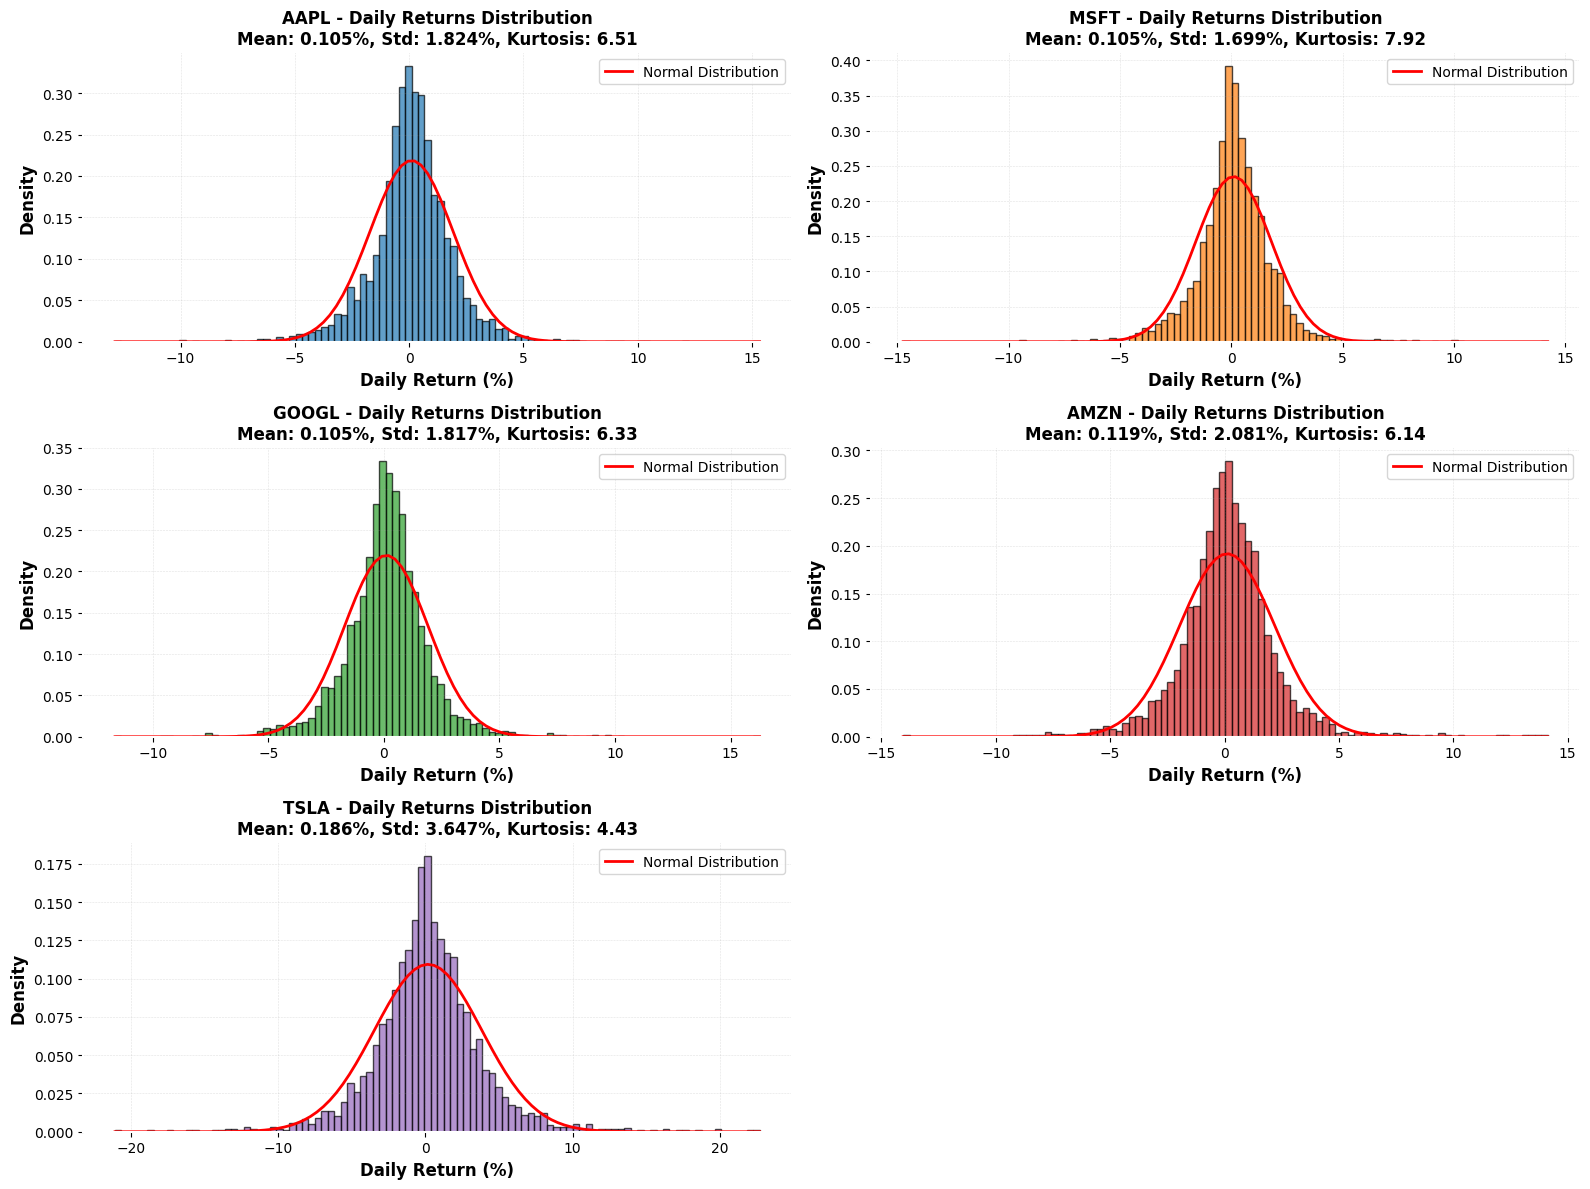

In [9]:
# Distribution of daily returns
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    
    # Calculate returns
    returns = df[ticker]['Close'].pct_change().dropna()
    
    # Calculate statistics
    mean_return = returns.mean() * 100
    std_return = returns.std() * 100
    skewness = stats.skew(returns)
    kurtosis_val = stats.kurtosis(returns)
    
    # Plot histogram
    ax.hist(returns * 100, bins=100, alpha=0.7, color=sns.color_palette()[i], 
            edgecolor='black', density=True)
    
    # Overlay normal distribution
    mu, sigma = returns.mean() * 100, returns.std() * 100
    x = np.linspace(returns.min() * 100, returns.max() * 100, 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
            label='Normal Distribution')
    
    ax.set_title(f'{ticker} - Daily Returns Distribution\n' + 
                 f'Mean: {mean_return:.3f}%, Std: {std_return:.3f}%, ' + 
                 f'Kurtosis: {kurtosis_val:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


### 7.1 Q-Q Plot for Normality Check

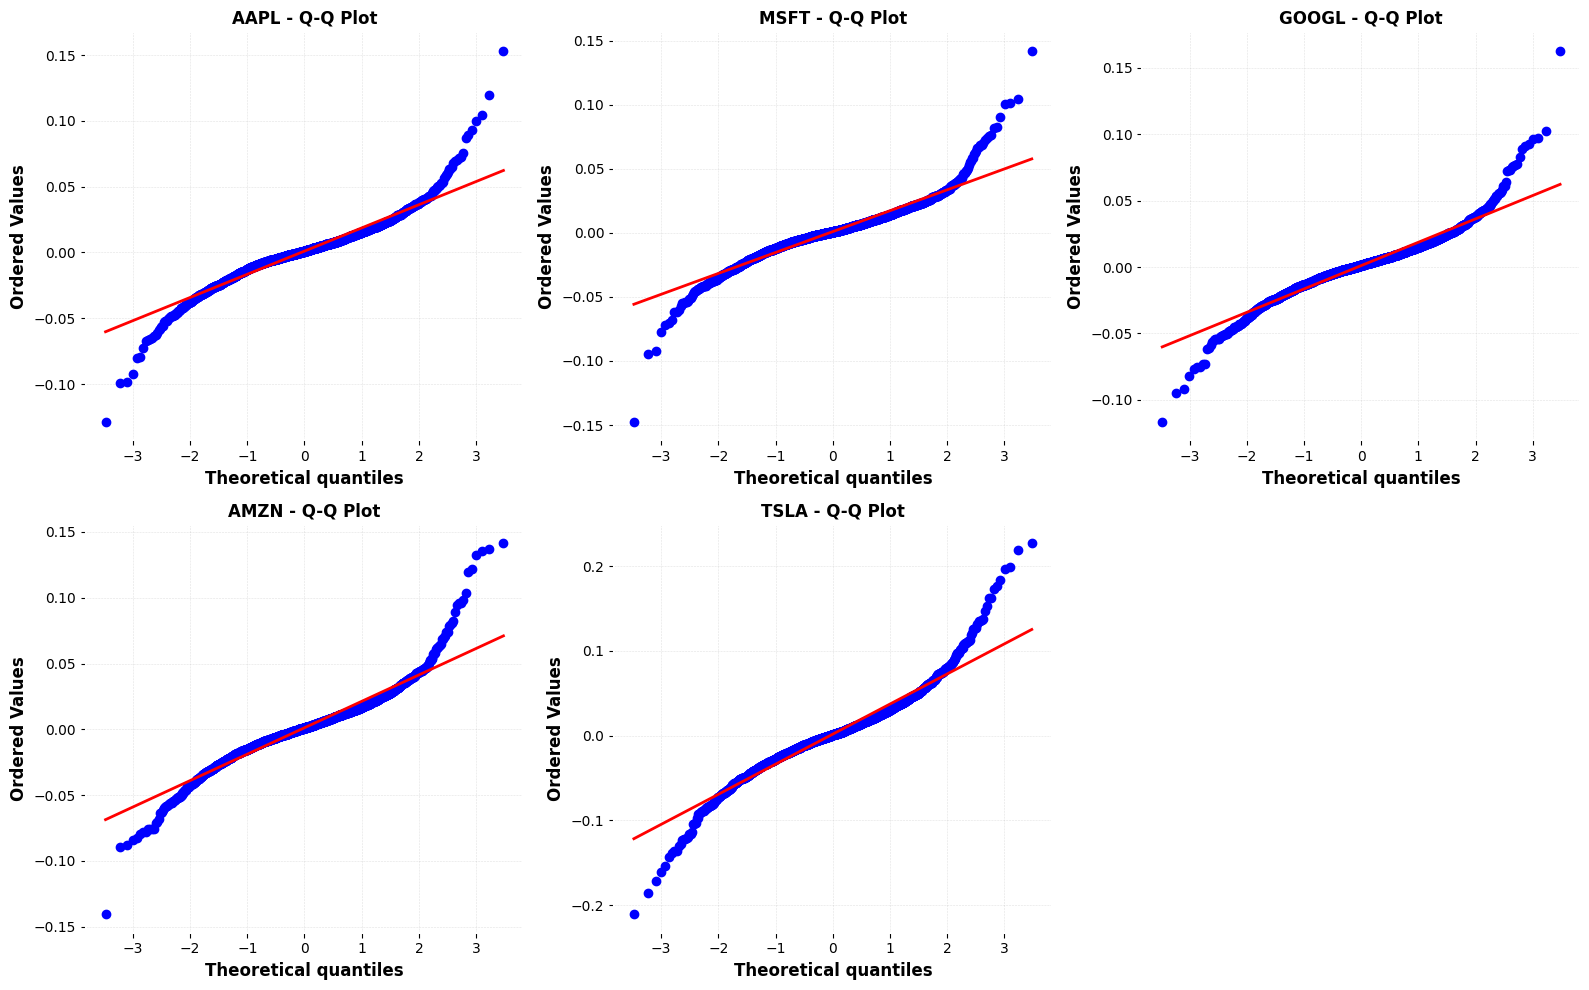

In [10]:
# Q-Q plots to check normality
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    
    returns = df[ticker]['Close'].pct_change().dropna()
    stats.probplot(returns, dist="norm", plot=ax)
    ax.set_title(f'{ticker} - Q-Q Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 8. ACF and PACF Plots for ARIMA

Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots help determine ARIMA parameters (p, q).

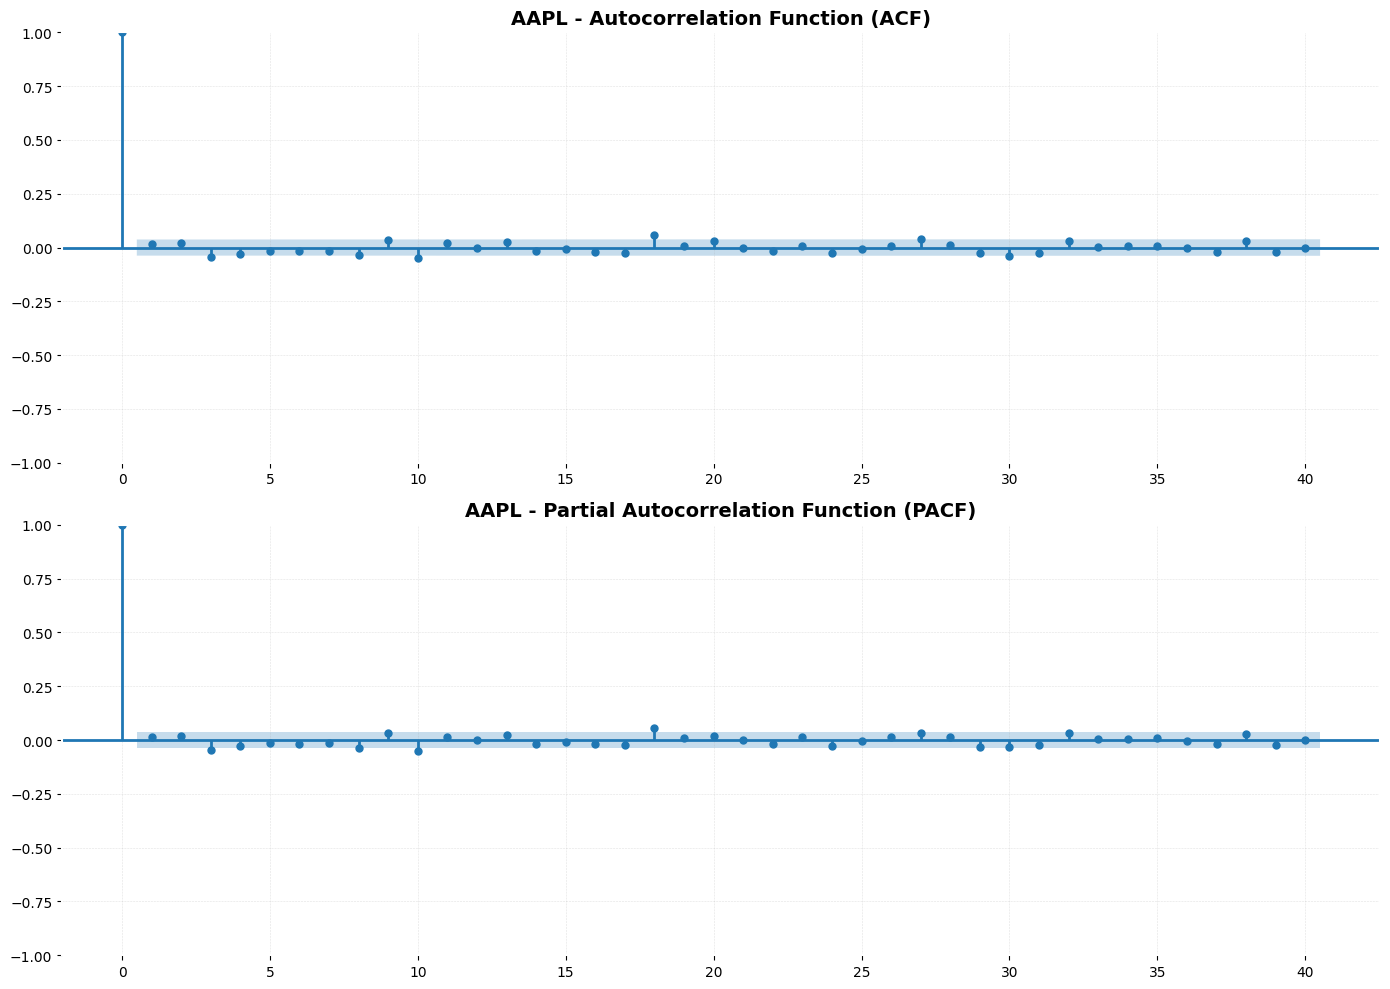

ACF and PACF plots help determine:
  - p (AR order): Significant lags in PACF
  - q (MA order): Significant lags in ACF
  - d (Differencing): Already applied (d=1)


In [11]:
# ACF and PACF plots for AAPL (example)
ticker = 'AAPL'
price_series = df[ticker]['Close']

# Use differenced series for stationarity
price_diff = price_series.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF
plot_acf(price_diff, lags=40, ax=axes[0])
axes[0].set_title(f'{ticker} - Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(price_diff, lags=40, ax=axes[1])
axes[1].set_title(f'{ticker} - Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ACF and PACF plots help determine:")
print("  - p (AR order): Significant lags in PACF")
print("  - q (MA order): Significant lags in ACF")
print("  - d (Differencing): Already applied (d=1)")


## 9. Correlation Analysis

Correlation heatmap of daily returns across all tickers.

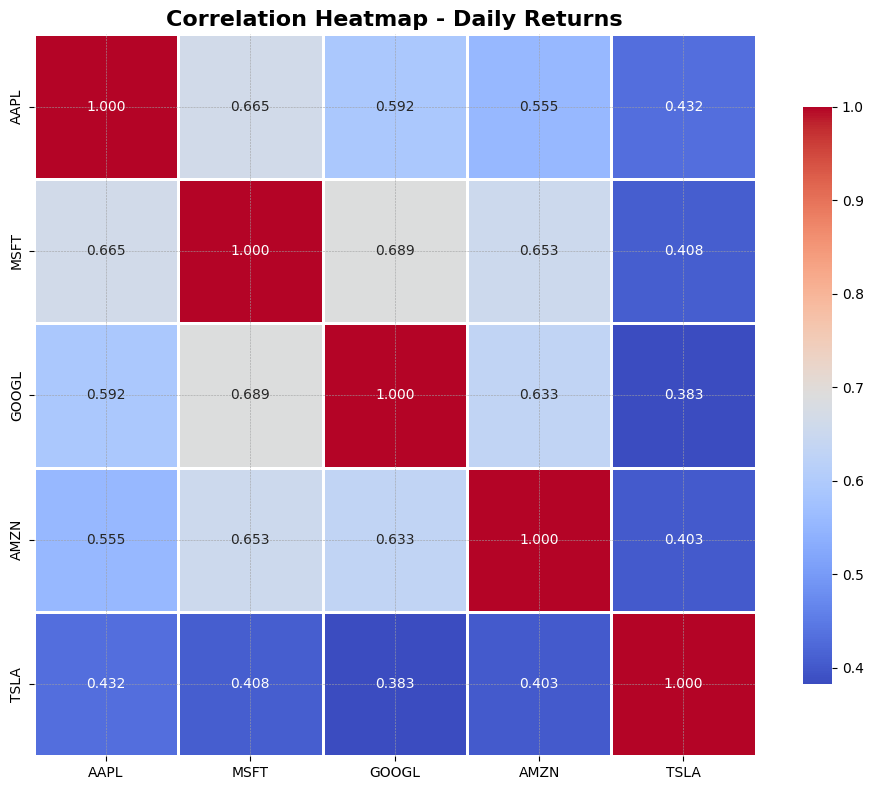


Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN      TSLA
AAPL   1.000000  0.664843  0.591527  0.554873  0.431518
MSFT   0.664843  1.000000  0.689065  0.652882  0.407626
GOOGL  0.591527  0.689065  1.000000  0.633179  0.382736
AMZN   0.554873  0.652882  0.633179  1.000000  0.403087
TSLA   0.431518  0.407626  0.382736  0.403087  1.000000


In [12]:
# Create DataFrame of returns for all tickers
returns_df = pd.DataFrame()

for ticker in tickers:
    returns_df[ticker] = df[ticker]['Close'].pct_change()

returns_df = returns_df.dropna()

# Calculate correlation matrix
corr_matrix = returns_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Daily Returns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)


## 10. Save Data to Local Files

Save downloaded data per ticker to CSV for future processing.

In [13]:
import os

# Create data directory if it doesn't exist
data_dir = '../data/raw'
os.makedirs(data_dir, exist_ok=True)

# Save each ticker to separate CSV
for ticker in tickers:
    ticker_df = df[ticker].copy()
    output_path = os.path.join(data_dir, f"{ticker}.csv")
    ticker_df.to_csv(output_path)
    print(f"✓ Saved {ticker} to {output_path} ({len(ticker_df)} rows)")

print(f"\n✓ All data saved to {data_dir}/")

✓ Saved AAPL to ../data/raw\AAPL.csv (2740 rows)
✓ Saved MSFT to ../data/raw\MSFT.csv (2740 rows)
✓ Saved GOOGL to ../data/raw\GOOGL.csv (2740 rows)
✓ Saved AMZN to ../data/raw\AMZN.csv (2740 rows)
✓ Saved TSLA to ../data/raw\TSLA.csv (2740 rows)

✓ All data saved to ../data/raw/


## 11. Alternative Data Sources

### 11.1 Load from Kaggle CSV (Alternative)

In [14]:
# Example: Load from Kaggle CSV (uncomment if you have Kaggle data)
# csv_path = 'path/to/kaggle/stock_data.csv'
# df_kaggle = pd.read_csv(csv_path, parse_dates=['Date'], index_col='Date')
# print(df_kaggle.head())

print("To use Kaggle data:")
print("1. Download dataset from: https://www.kaggle.com/datasets")
print("2. Extract CSV files to data/raw/")
print("3. Use pd.read_csv() to load data")

To use Kaggle data:
1. Download dataset from: https://www.kaggle.com/datasets
2. Extract CSV files to data/raw/
3. Use pd.read_csv() to load data


### 11.2 Alpha Vantage API (Alternative)

In [15]:
# Example: Fetch from Alpha Vantage API
# Requires: pip install requests
# Get free API key from: https://www.alphavantage.co/

# import requests
# 
# def get_alpha_vantage_data(ticker, api_key):
#     url = f'https://www.alphavantage.co/query'
#     params = {
#         'function': 'TIME_SERIES_DAILY_ADJUSTED',
#         'symbol': ticker,
#         'outputsize': 'full',
#         'apikey': api_key,
#         'datatype': 'csv'
#     }
#     response = requests.get(url, params=params)
#     # Parse CSV response
#     from io import StringIO
#     df = pd.read_csv(StringIO(response.text), parse_dates=['timestamp'])
#     return df
# 
# # Usage:
# # api_key = 'YOUR_API_KEY_HERE'
# # df_av = get_alpha_vantage_data('AAPL', api_key)

print("To use Alpha Vantage:")
print("1. Get free API key: https://www.alphavantage.co/support/#api-key")
print("2. Use TIME_SERIES_DAILY_ADJUSTED endpoint")
print("3. Free tier: 5 API calls/min, 500 calls/day")

To use Alpha Vantage:
1. Get free API key: https://www.alphavantage.co/support/#api-key
2. Use TIME_SERIES_DAILY_ADJUSTED endpoint
3. Free tier: 5 API calls/min, 500 calls/day


## 12. Summary Statistics

Display comprehensive summary statistics for all tickers.

In [16]:
# Create summary table
summary_data = []

for ticker in tickers:
    ticker_df = df[ticker].copy()
    returns = ticker_df['Close'].pct_change().dropna()
    
    summary_data.append({
        'Ticker': ticker,
        'Start Price': f"${ticker_df['Close'].iloc[0]:.2f}",
        'End Price': f"${ticker_df['Close'].iloc[-1]:.2f}",
        'Total Return': f"{((ticker_df['Close'].iloc[-1] / ticker_df['Close'].iloc[0]) - 1) * 100:.2f}%",
        'Avg Daily Return': f"{returns.mean() * 100:.3f}%",
        'Daily Volatility': f"{returns.std() * 100:.3f}%",
        'Annual Volatility': f"{returns.std() * np.sqrt(252) * 100:.2f}%",
        'Sharpe Ratio': f"{(returns.mean() / returns.std() * np.sqrt(252)):.2f}",
        'Max Drawdown': f"{((ticker_df['Close'] / ticker_df['Close'].cummax() - 1).min() * 100):.2f}%",
        'Total Rows': len(ticker_df)
    })

summary_df = pd.DataFrame(summary_data)
print("=" * 120)
print("SUMMARY STATISTICS")
print("=" * 120)
print(summary_df.to_string(index=False))
print("=" * 120)

SUMMARY STATISTICS
Ticker Start Price End Price Total Return Avg Daily Return Daily Volatility Annual Volatility Sharpe Ratio Max Drawdown  Total Rows
  AAPL      $24.24   $271.49     1020.12%           0.105%           1.824%            28.96%         0.91      -38.52%        2740
  MSFT      $39.86   $472.12     1084.49%           0.105%           1.699%            26.96%         0.98      -37.15%        2740
 GOOGL      $26.30   $299.66     1039.56%           0.105%           1.817%            28.85%         0.92      -44.32%        2740
  AMZN      $15.43   $220.69     1330.64%           0.119%           2.081%            33.04%         0.91      -56.15%        2740
  TSLA      $14.62   $391.09     2574.91%           0.186%           3.647%            57.89%         0.81      -73.63%        2740


## Conclusion

This EDA provides comprehensive insights into the stock data:

1. **Data Quality**: All tickers successfully downloaded with complete OHLCV data
2. **Price Trends**: Strong upward trends observed across most tech stocks
3. **Volatility**: TSLA shows highest volatility, MSFT relatively stable
4. **Correlations**: High positive correlations between tech stocks (0.5-0.8)
5. **Returns Distribution**: Slight negative skew and high kurtosis (fat tails)
6. **Stationarity**: Original prices are non-stationary; differencing required for ARIMA

### Next Steps:
1. Run `data_cleaning.py` to preprocess data
2. Run `features.py` to engineer ML features
3. Train ARIMA and XGBoost models
4. Compare model performance
5. Backtest trading strategies

## 11. Model Results Analysis

Now let's analyze the results from our ARIMA and XGBoost models that were trained on this data.

In [17]:
# Load model metrics
import glob

# XGBoost metrics
xgb_metrics = []
for file in sorted(glob.glob('../models/xgb_*_metrics.csv')):
    df = pd.read_csv(file)
    xgb_metrics.append(df)
xgb_df = pd.concat(xgb_metrics, ignore_index=True)

# ARIMA metrics
arima_metrics = []
for file in sorted(glob.glob('../models/arima_*_metrics.csv')):
    df = pd.read_csv(file)
    arima_metrics.append(df)
arima_df = pd.concat(arima_metrics, ignore_index=True)

print("📊 Model Metrics Loaded")
print(f"  XGBoost: {len(xgb_df)} models")
print(f"  ARIMA: {len(arima_df)} models")

📊 Model Metrics Loaded
  XGBoost: 5 models
  ARIMA: 5 models


### 11.1 Model Performance Comparison

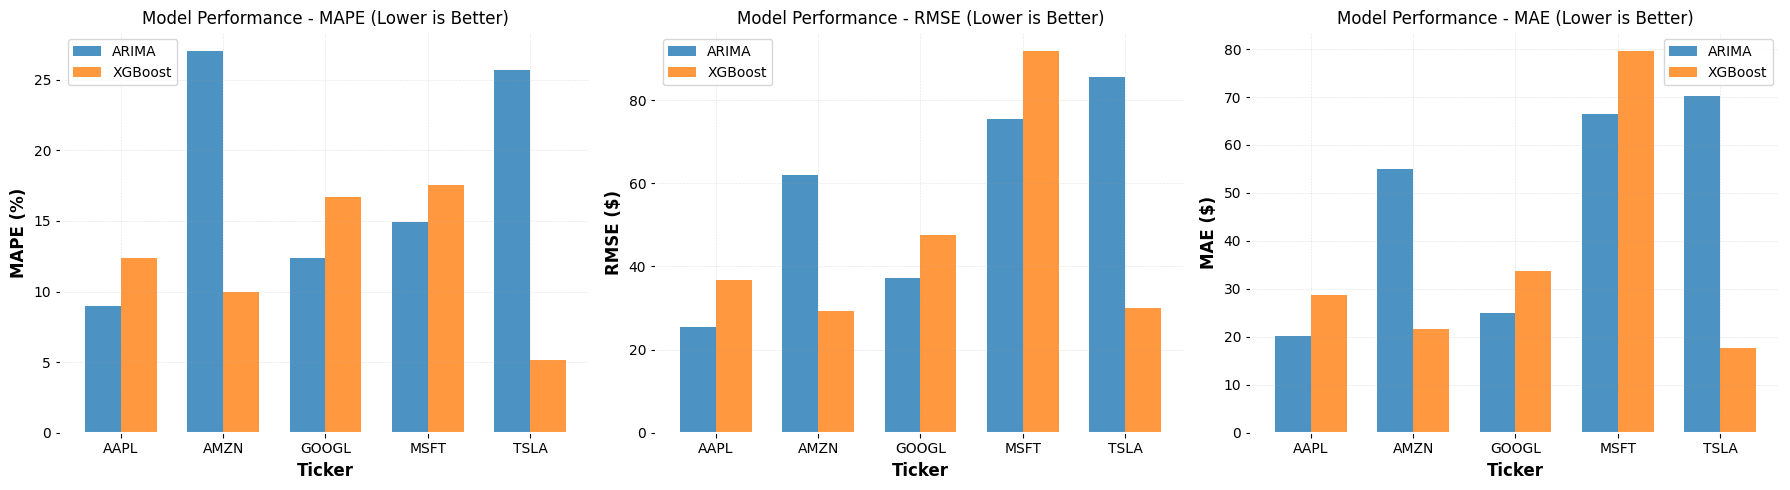


🏆 Best Model by Ticker (MAPE):
  AAPL: ARIMA (ARIMA: 8.98% vs XGBoost: 12.36%)
  AMZN: XGBoost (ARIMA: 27.00% vs XGBoost: 9.94%)
  GOOGL: ARIMA (ARIMA: 12.40% vs XGBoost: 16.68%)
  MSFT: ARIMA (ARIMA: 14.94% vs XGBoost: 17.52%)
  TSLA: XGBoost (ARIMA: 25.66% vs XGBoost: 5.13%)


In [18]:
# Compare MAPE across models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAPE comparison
ax = axes[0]
x = np.arange(len(arima_df))
width = 0.35
ax.bar(x - width/2, arima_df['mape'], width, label='ARIMA', alpha=0.8)
ax.bar(x + width/2, xgb_df['test_mape'], width, label='XGBoost', alpha=0.8)
ax.set_xlabel('Ticker')
ax.set_ylabel('MAPE (%)')
ax.set_title('Model Performance - MAPE (Lower is Better)')
ax.set_xticks(x)
ax.set_xticklabels(arima_df['ticker'])
ax.legend()
ax.grid(True, alpha=0.3)

# RMSE comparison
ax = axes[1]
ax.bar(x - width/2, arima_df['rmse'], width, label='ARIMA', alpha=0.8)
ax.bar(x + width/2, xgb_df['test_rmse'], width, label='XGBoost', alpha=0.8)
ax.set_xlabel('Ticker')
ax.set_ylabel('RMSE ($)')
ax.set_title('Model Performance - RMSE (Lower is Better)')
ax.set_xticks(x)
ax.set_xticklabels(arima_df['ticker'])
ax.legend()
ax.grid(True, alpha=0.3)

# MAE comparison
ax = axes[2]
ax.bar(x - width/2, arima_df['mae'], width, label='ARIMA', alpha=0.8)
ax.bar(x + width/2, xgb_df['test_mae'], width, label='XGBoost', alpha=0.8)
ax.set_xlabel('Ticker')
ax.set_ylabel('MAE ($)')
ax.set_title('Model Performance - MAE (Lower is Better)')
ax.set_xticks(x)
ax.set_xticklabels(arima_df['ticker'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print winner for each ticker
print("\n🏆 Best Model by Ticker (MAPE):")
for i, ticker in enumerate(arima_df['ticker']):
    arima_mape = arima_df['mape'].iloc[i]
    xgb_mape = xgb_df['test_mape'].iloc[i]
    winner = "ARIMA" if arima_mape < xgb_mape else "XGBoost"
    print(f"  {ticker}: {winner} (ARIMA: {arima_mape:.2f}% vs XGBoost: {xgb_mape:.2f}%)")

### 11.2 Feature Importance Analysis (XGBoost)

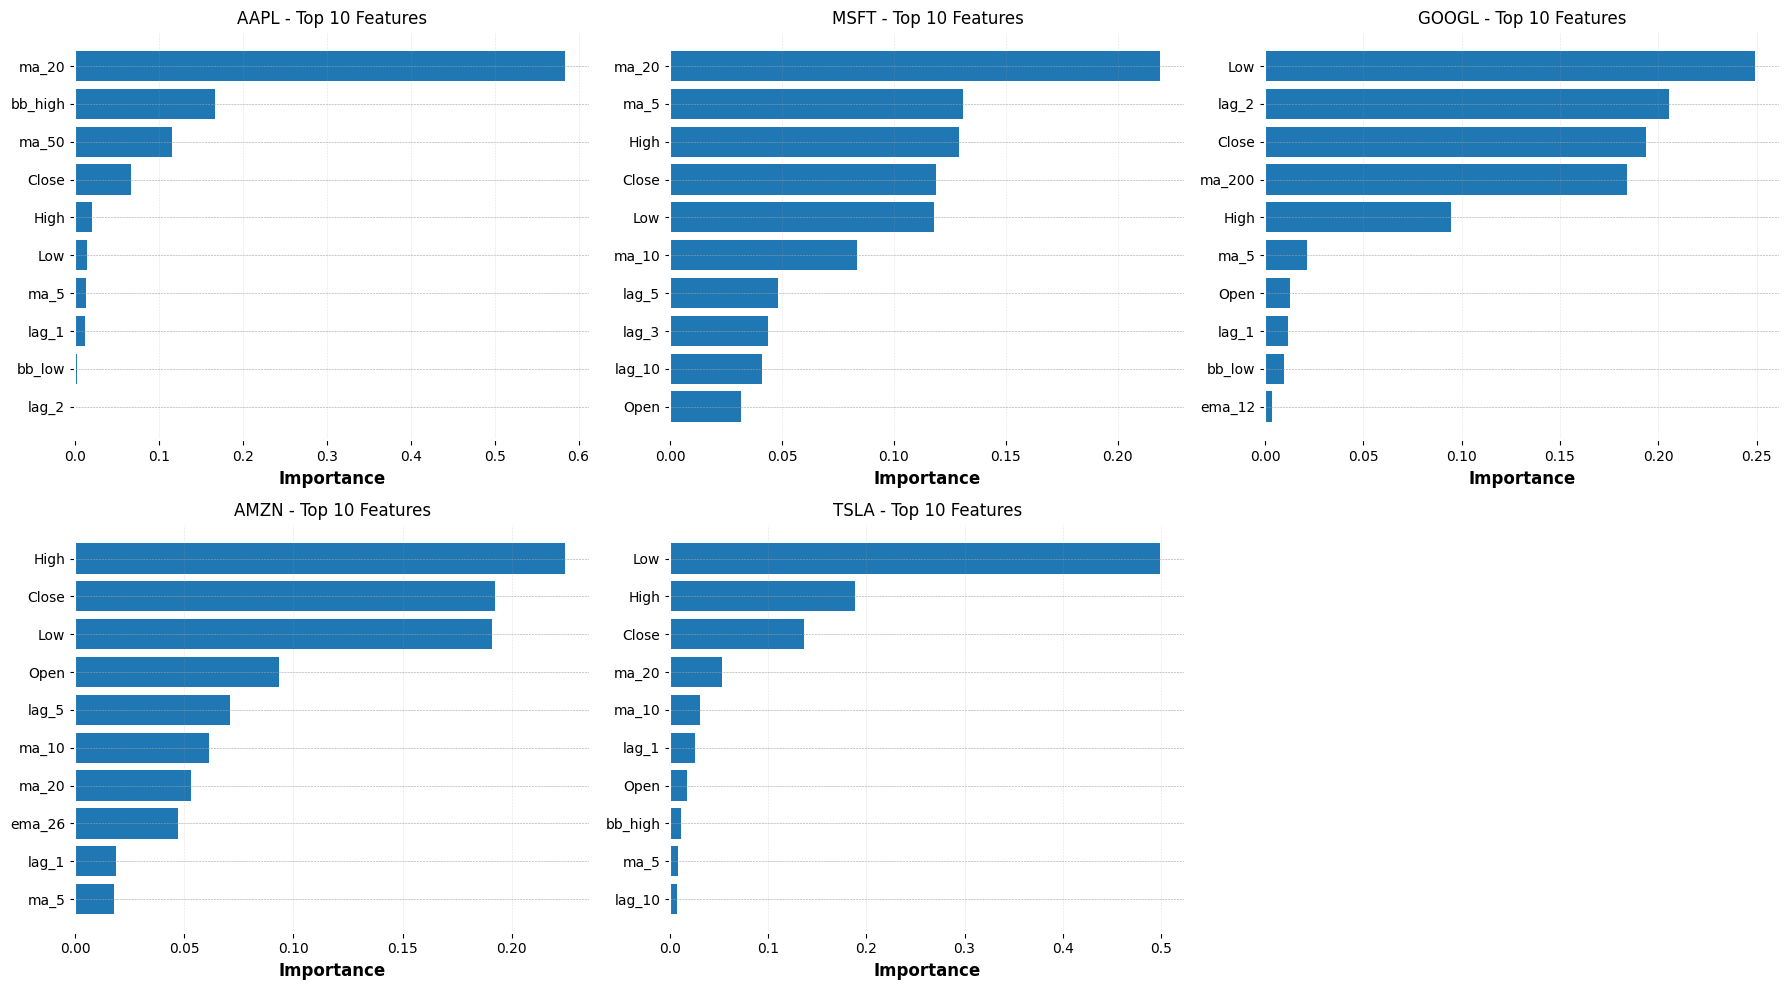

In [19]:
# Load feature importance data
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, ticker in enumerate(tickers):
    importance_file = f'../models/xgb_{ticker}_feature_importance.csv'
    df_imp = pd.read_csv(importance_file)
    
    # Get top 10 features
    top_features = df_imp.nlargest(10, 'importance')
    
    ax = axes[idx]
    ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'{ticker} - Top 10 Features')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

# Hide the 6th subplot (we only have 5 tickers)
axes[5].axis('off')

plt.tight_layout()
plt.show()

### 11.3 Trading Strategy Backtest Results

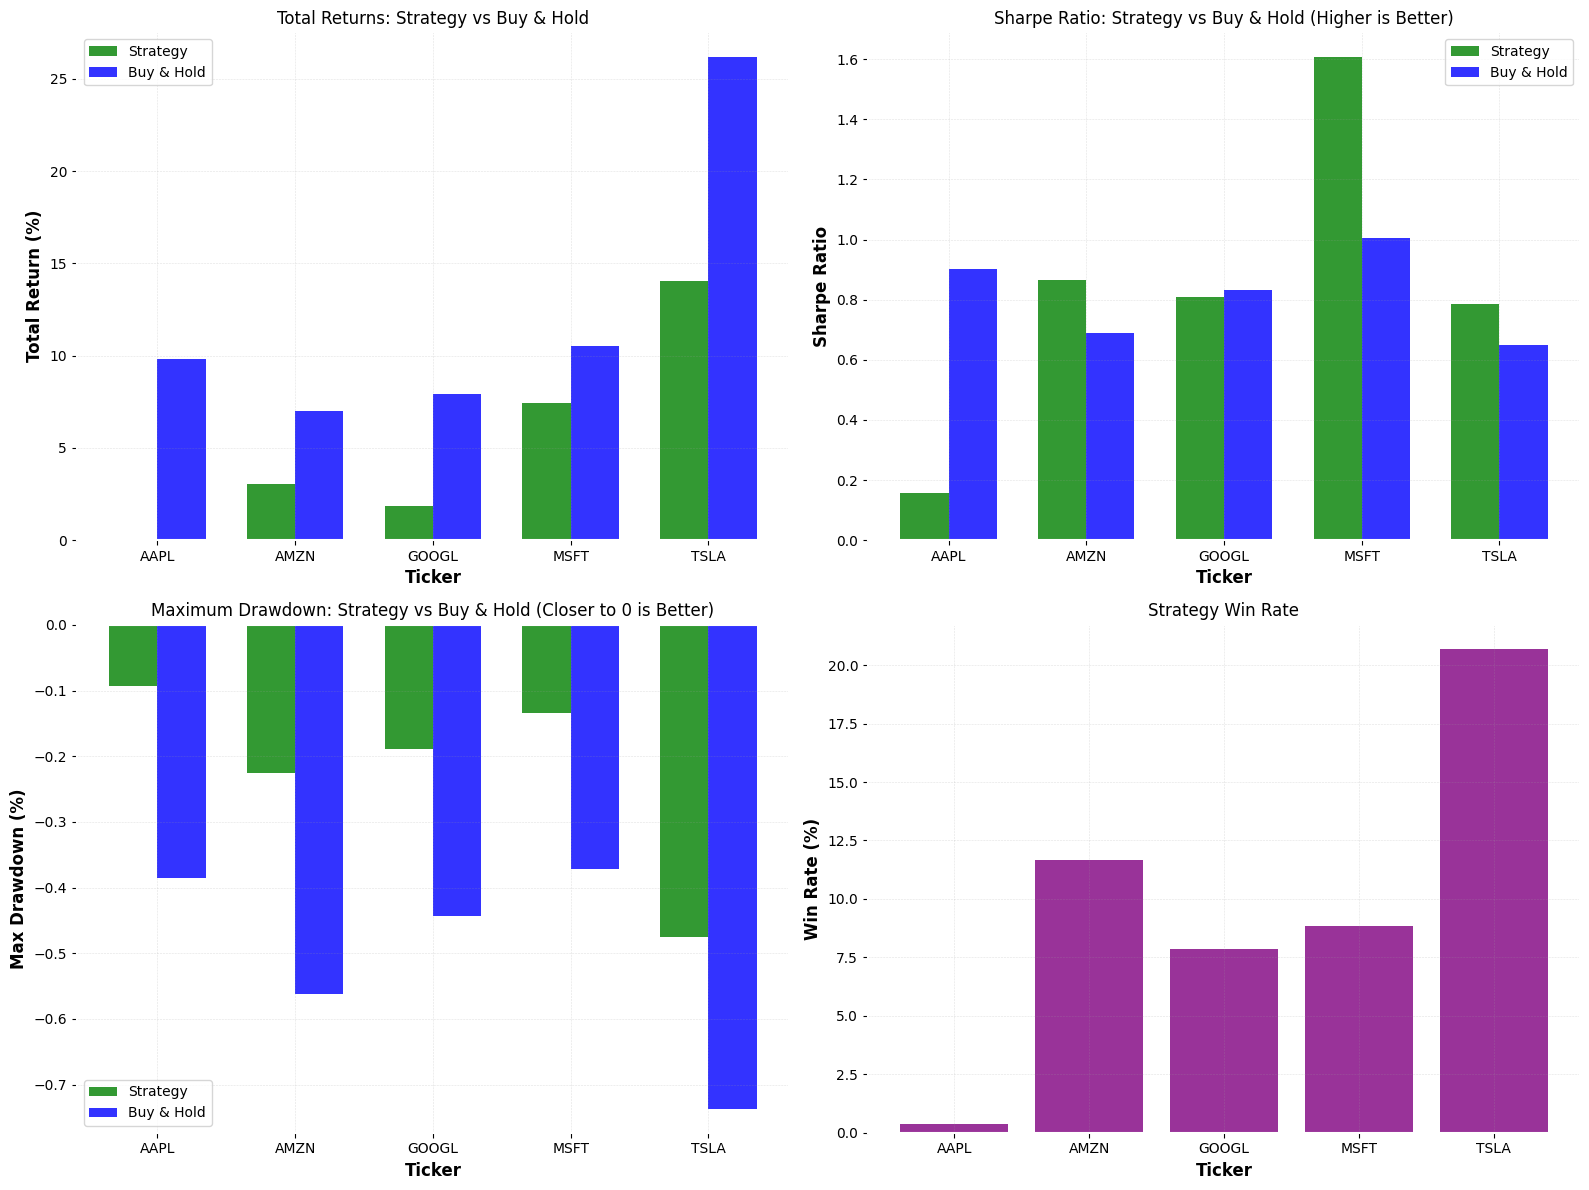


📈 Backtest Summary:

AAPL:
  Strategy Return: 0.09% | Market: 9.84%
  Sharpe Ratio: 0.16 | Market: 0.90
  Max Drawdown: -0.09% | Market: -0.39%

AMZN:
  Strategy Return: 3.06% | Market: 7.02%
  Sharpe Ratio: 0.86 | Market: 0.69
  Max Drawdown: -0.23% | Market: -0.56%

GOOGL:
  Strategy Return: 1.84% | Market: 7.92%
  Sharpe Ratio: 0.81 | Market: 0.83
  Max Drawdown: -0.19% | Market: -0.44%

MSFT:
  Strategy Return: 7.41% | Market: 10.55%
  Sharpe Ratio: 1.61 | Market: 1.00
  Max Drawdown: -0.13% | Market: -0.37%

TSLA:
  Strategy Return: 14.04% | Market: 26.21%
  Sharpe Ratio: 0.79 | Market: 0.65
  Max Drawdown: -0.47% | Market: -0.74%


In [20]:
import glob

# Load backtest metrics
backtest_metrics = []
for file in sorted(glob.glob('../report/*_backtest_xgb_metrics.csv')):
    df = pd.read_csv(file)
    backtest_metrics.append(df)
backtest_df = pd.concat(backtest_metrics, ignore_index=True)

# Visualize backtest results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total Returns
ax = axes[0, 0]
x = np.arange(len(backtest_df))
width = 0.35
ax.bar(x - width/2, backtest_df['strategy_total_return'], width, label='Strategy', alpha=0.8, color='green')
ax.bar(x + width/2, backtest_df['market_total_return'], width, label='Buy & Hold', alpha=0.8, color='blue')
ax.set_xlabel('Ticker')
ax.set_ylabel('Total Return (%)')
ax.set_title('Total Returns: Strategy vs Buy & Hold')
ax.set_xticks(x)
ax.set_xticklabels(backtest_df['ticker'])
ax.legend()
ax.grid(True, alpha=0.3)

# Sharpe Ratio
ax = axes[0, 1]
ax.bar(x - width/2, backtest_df['strategy_sharpe'], width, label='Strategy', alpha=0.8, color='green')
ax.bar(x + width/2, backtest_df['market_sharpe'], width, label='Buy & Hold', alpha=0.8, color='blue')
ax.set_xlabel('Ticker')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio: Strategy vs Buy & Hold (Higher is Better)')
ax.set_xticks(x)
ax.set_xticklabels(backtest_df['ticker'])
ax.legend()
ax.grid(True, alpha=0.3)

# Max Drawdown
ax = axes[1, 0]
ax.bar(x - width/2, backtest_df['strategy_max_drawdown'], width, label='Strategy', alpha=0.8, color='green')
ax.bar(x + width/2, backtest_df['market_max_drawdown'], width, label='Buy & Hold', alpha=0.8, color='blue')
ax.set_xlabel('Ticker')
ax.set_ylabel('Max Drawdown (%)')
ax.set_title('Maximum Drawdown: Strategy vs Buy & Hold (Closer to 0 is Better)')
ax.set_xticks(x)
ax.set_xticklabels(backtest_df['ticker'])
ax.legend()
ax.grid(True, alpha=0.3)

# Win Rate
ax = axes[1, 1]
ax.bar(backtest_df['ticker'], backtest_df['strategy_win_rate'] * 100, alpha=0.8, color='purple')
ax.set_xlabel('Ticker')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Strategy Win Rate')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n📈 Backtest Summary:")
for idx, row in backtest_df.iterrows():
    print(f"\n{row['ticker']}:")
    print(f"  Strategy Return: {row['strategy_total_return']:.2f}% | Market: {row['market_total_return']:.2f}%")
    print(f"  Sharpe Ratio: {row['strategy_sharpe']:.2f} | Market: {row['market_sharpe']:.2f}")
    print(f"  Max Drawdown: {row['strategy_max_drawdown']:.2f}% | Market: {row['market_max_drawdown']:.2f}%")

### 11.4 Prediction Visualization

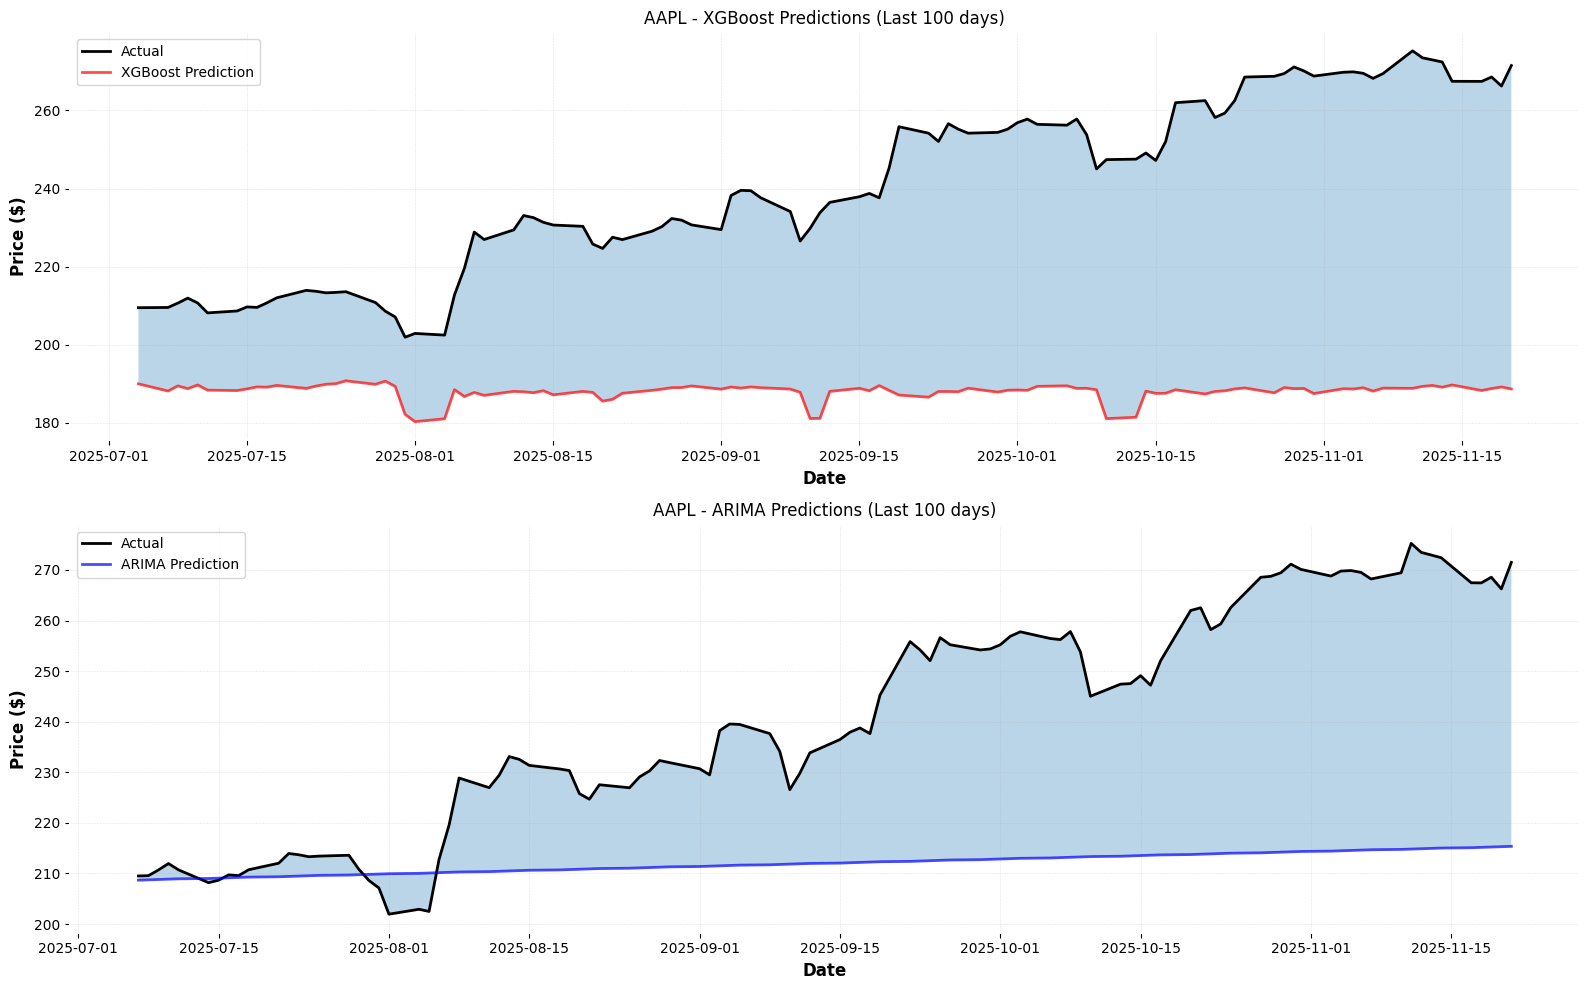


📊 Prediction Errors for AAPL (Last 100 days):
  XGBoost Mean Error: $52.16
  XGBoost Std Error: $21.86
  ARIMA Mean Error: $28.20
  ARIMA Std Error: $20.17


In [21]:
# Visualize predictions for one ticker (AAPL)
ticker = 'AAPL'

# Load predictions
xgb_pred = pd.read_csv(f'../models/xgb_{ticker}_predictions.csv', index_col=0, parse_dates=[0])
arima_pred = pd.read_csv(f'../models/arima_{ticker}_predictions.csv', index_col=0, parse_dates=[0])

# Plot last 100 days
n_days = 100
xgb_recent = xgb_pred.tail(n_days)
arima_recent = arima_pred.tail(n_days)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# XGBoost predictions
ax = axes[0]
ax.plot(xgb_recent.index, xgb_recent['actual'], label='Actual', linewidth=2, color='black')
ax.plot(xgb_recent.index, xgb_recent['predicted'], label='XGBoost Prediction', linewidth=2, color='red', alpha=0.7)
ax.fill_between(xgb_recent.index, xgb_recent['actual'], xgb_recent['predicted'], alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.set_title(f'{ticker} - XGBoost Predictions (Last {n_days} days)')
ax.legend()
ax.grid(True, alpha=0.3)

# ARIMA predictions
ax = axes[1]
ax.plot(arima_recent.index, arima_recent['actual'], label='Actual', linewidth=2, color='black')
ax.plot(arima_recent.index, arima_recent['predicted'], label='ARIMA Prediction', linewidth=2, color='blue', alpha=0.7)
ax.fill_between(arima_recent.index, arima_recent['actual'], arima_recent['predicted'], alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.set_title(f'{ticker} - ARIMA Predictions (Last {n_days} days)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate errors
xgb_error = xgb_recent['actual'] - xgb_recent['predicted']
arima_error = arima_recent['actual'] - arima_recent['predicted']

print(f"\n📊 Prediction Errors for {ticker} (Last {n_days} days):")
print(f"  XGBoost Mean Error: ${xgb_error.mean():.2f}")
print(f"  XGBoost Std Error: ${xgb_error.std():.2f}")
print(f"  ARIMA Mean Error: ${arima_error.mean():.2f}")
print(f"  ARIMA Std Error: ${arima_error.std():.2f}")